# Diabetes Dataset Exploration

Short exploratory notebook for the Phase 1 `sklearn` Diabetes dataset.
It reuses the project loader and preprocessing logic so the notebook stays aligned with the experiment code.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

In [5]:
# Imported code:
# from src.data.load_diabetes import load_diabetes_dataset
# from src.data.preprocessing import prepare_diabetes_tabular_data

from __future__ import annotations
from dataclasses import dataclass
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

@dataclass(frozen=True)
class DatasetBundle:
    dataset_name: str
    features: pd.DataFrame
    target: pd.Series
    
def load_diabetes_dataset() -> DatasetBundle:
    """Load the sklearn Diabetes regression dataset into a reusable bundle."""
    dataset = load_diabetes(as_frame=True)

    features = dataset.data.copy()
    target = dataset.target.rename("target").copy()

    return DatasetBundle(
        dataset_name="diabetes",
        features=features,
        target=target,
    )

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DEFAULT_RANDOM_STATE = 42

@dataclass(frozen=True)
class SplitIndices:
    train: np.ndarray
    val: np.ndarray
    test: np.ndarray


@dataclass(frozen=True)
class TabularDataSplit:
    dataset_name: str
    feature_names: list[str]
    train_indices: np.ndarray
    val_indices: np.ndarray
    test_indices: np.ndarray
    x_train_raw: np.ndarray
    x_val_raw: np.ndarray
    x_test_raw: np.ndarray
    x_train_scaled: np.ndarray
    x_val_scaled: np.ndarray
    x_test_scaled: np.ndarray
    y_train: np.ndarray
    y_val: np.ndarray
    y_test: np.ndarray


def create_split_indices(
    num_samples: int,
    *,
    train_size: float = 0.6,
    val_size: float = 0.2,
    test_size: float = 0.2,
    random_state: int = DEFAULT_RANDOM_STATE,
) -> SplitIndices:
    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train_size, val_size, and test_size must sum to 1.0.")

    all_indices = np.arange(num_samples)
    train_indices, temp_indices = train_test_split(
        all_indices,
        train_size=train_size,
        random_state=random_state,
        shuffle=True,
    )

    val_fraction_of_temp = val_size / (val_size + test_size)
    val_indices, test_indices = train_test_split(
        temp_indices,
        train_size=val_fraction_of_temp,
        random_state=random_state,
        shuffle=True,
    )

    return SplitIndices(
        train=np.sort(train_indices),
        val=np.sort(val_indices),
        test=np.sort(test_indices),
    )


def prepare_diabetes_tabular_data(
    dataset: DatasetBundle,
    *,
    random_state: int = DEFAULT_RANDOM_STATE,
) -> TabularDataSplit:
    features = dataset.features.copy()
    target = dataset.target.copy()

    split_indices = create_split_indices(
        len(features),
        random_state=random_state,
    )

    x_train_raw = features.iloc[split_indices.train].to_numpy(dtype=np.float64)
    x_val_raw = features.iloc[split_indices.val].to_numpy(dtype=np.float64)
    x_test_raw = features.iloc[split_indices.test].to_numpy(dtype=np.float64)

    y_train = target.iloc[split_indices.train].to_numpy(dtype=np.float64)
    y_val = target.iloc[split_indices.val].to_numpy(dtype=np.float64)
    y_test = target.iloc[split_indices.test].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_raw)
    x_val_scaled = scaler.transform(x_val_raw)
    x_test_scaled = scaler.transform(x_test_raw)

    return TabularDataSplit(
        dataset_name=dataset.dataset_name,
        feature_names=list(features.columns),
        train_indices=split_indices.train,
        val_indices=split_indices.val,
        test_indices=split_indices.test,
        x_train_raw=x_train_raw,
        x_val_raw=x_val_raw,
        x_test_raw=x_test_raw,
        x_train_scaled=x_train_scaled,
        x_val_scaled=x_val_scaled,
        x_test_scaled=x_test_scaled,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
    )

In [6]:
dataset = load_diabetes_dataset()
df = dataset.features.copy()
df["target"] = dataset.target

print(f"Dataset: {dataset.dataset_name}")
print(f"Rows: {df.shape[0]}")
print(f"Features: {dataset.features.shape[1]}")
df.head()

Dataset: diabetes
Rows: 442
Features: 10


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [7]:
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "mean": df.mean(numeric_only=True),
        "std": df.std(numeric_only=True),
        "min": df.min(numeric_only=True),
        "max": df.max(numeric_only=True),
    }
)
summary

,dtype,missing_values,mean,std,min,max
age,float64,0,-2.511817e-19,0.047619,-0.107226,0.110727
sex,float64,0,1.230790e-17,0.047619,-0.044642,0.050680
bmi,float64,0,-2.245564e-16,0.047619,-0.090275,0.170555
bp,float64,0,-4.797570e-17,0.047619,-0.112399,0.132044
s1,float64,0,-1.381499e-17,0.047619,-0.126781,0.153914
s2,float64,0,3.918434e-17,0.047619,-0.115613,0.198788
s3,float64,0,-5.777179e-18,0.047619,-0.102307,0.181179
s4,float64,0,-9.042540e-18,0.047619,-0.076395,0.185234
s5,float64,0,9.268604e-17,0.047619,-0.126097,0.133597
s6,float64,0,1.130318e-17,0.047619,-0.137767,0.135612


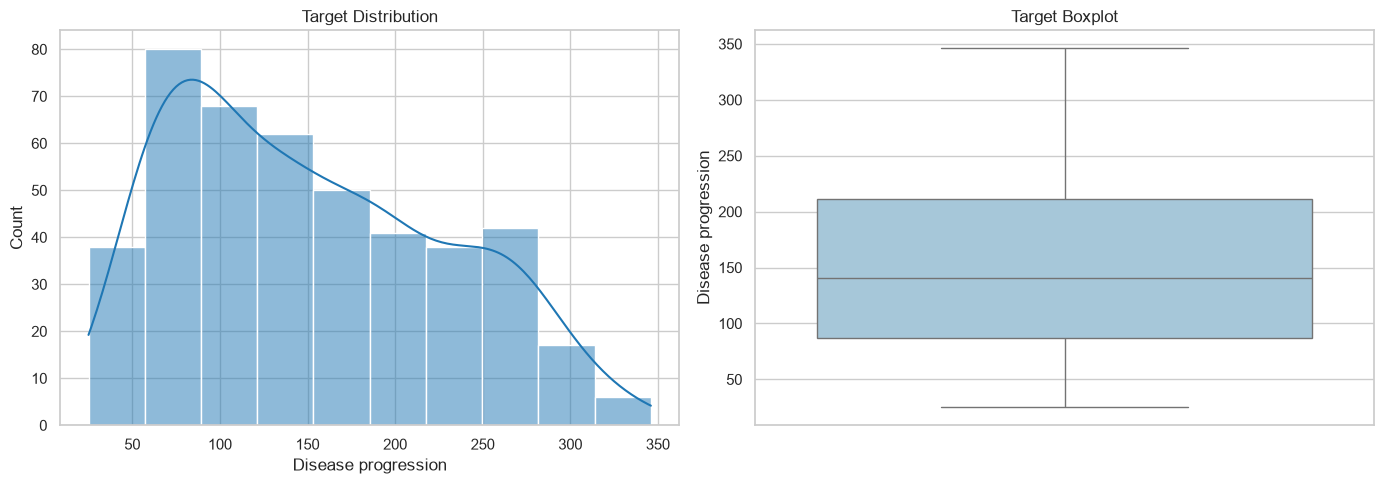

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["target"], kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Disease progression")

sns.boxplot(y=df["target"], ax=axes[1], color="#9ecae1")
axes[1].set_title("Target Boxplot")
axes[1].set_ylabel("Disease progression")

plt.tight_layout()

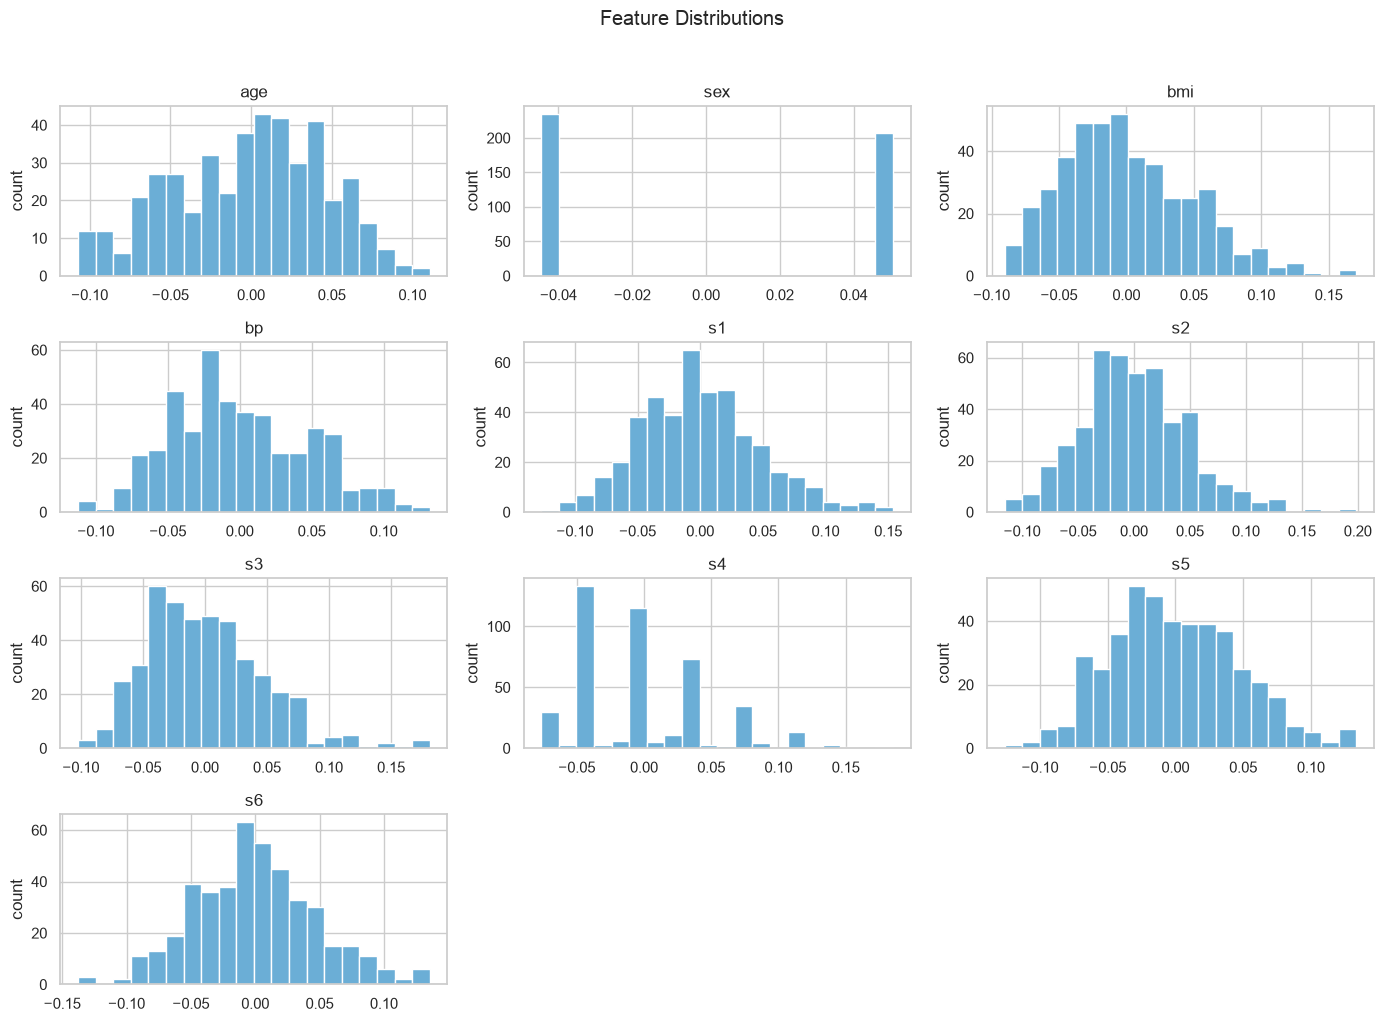

In [9]:
feature_axes = dataset.features.hist(figsize=(14, 10), bins=20, layout=(4, 3), color="#6baed6")
for ax in feature_axes.flatten():
    if ax is not None:
        ax.set_xlabel("")
        ax.set_ylabel("count")
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()

,corr_with_target
target,1.000000
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


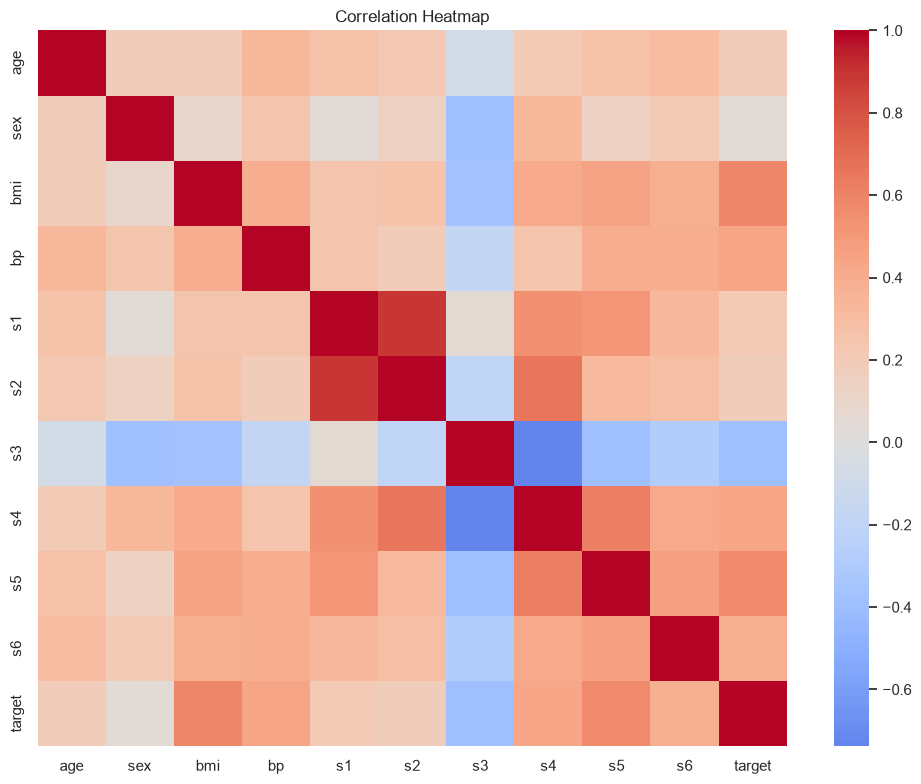

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()

corr["target"].sort_values(ascending=False).to_frame("corr_with_target")

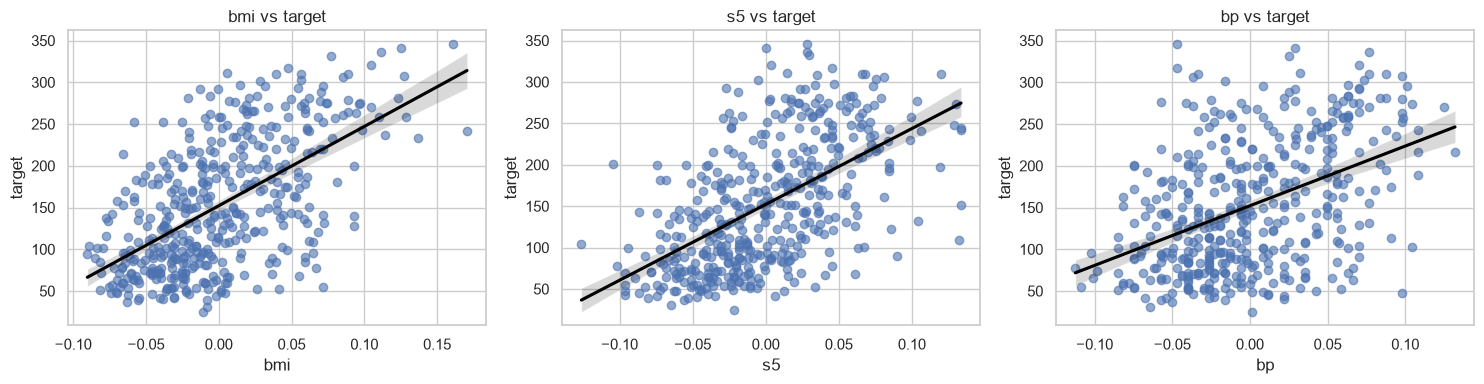

In [11]:
top_features = corr["target"].drop("target").abs().sort_values(ascending=False).head(3).index.tolist()
fig, axes = plt.subplots(1, len(top_features), figsize=(5 * len(top_features), 4))

if len(top_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, top_features):
    sns.regplot(data=df, x=feature, y="target", ax=ax, scatter_kws={"alpha": 0.6}, line_kws={"color": "black"})
    ax.set_title(f"{feature} vs target")

plt.tight_layout()

In [12]:
data_split = prepare_diabetes_tabular_data(dataset)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [
            len(data_split.train_indices),
            len(data_split.val_indices),
            len(data_split.test_indices),
        ],
        "target_mean": [
            data_split.y_train.mean(),
            data_split.y_val.mean(),
            data_split.y_test.mean(),
        ],
        "target_std": [
            data_split.y_train.std(),
            data_split.y_val.std(),
            data_split.y_test.std(),
        ],
    }
)
split_summary

,split,rows,target_mean,target_std
0,train,265,151.026415,77.330772
1,validation,88,145.056818,75.927052
2,test,89,162.426966,76.055995


In [13]:
scaled_train = pd.DataFrame(data_split.x_train_scaled, columns=data_split.feature_names)

pd.DataFrame(
    {
        "train_scaled_mean": scaled_train.mean(),
        "train_scaled_std": scaled_train.std(ddof=0),
    }
).head()

,train_scaled_mean,train_scaled_std
age,4.524683e-17,1.0
sex,-1.675808e-17,1.0
bmi,2.346132e-17,1.0
bp,-2.681293e-17,1.0
s1,-2.681293e-17,1.0


## Notes

- The Diabetes features are already normalized in the original `sklearn` dataset, but the project still applies train-only standardization for models that benefit from it.
- This notebook is intentionally lightweight and exploratory. Model training and metric reporting stay in `src/experiments/run_diabetes_experiment.py`.